In [84]:
library(DESeq2)
library(SummarizedExperiment)

In [85]:
setwd('/usr/users/papantonis1/aman/rnaseq_data/star_results')

In [86]:
fc <- read.table("../featurecounts_gene_counts.txt",
                  header = TRUE,
                  row.names = 1,
                  comment.char = "#",
                  check.names = FALSE)

In [87]:
count_matrix <- fc[ ,6:ncol(fc)]

In [88]:
count_matrix

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000290825.2,0,0,0,0,2,0
ENSG00000223972.6,0,0,0,0,0,0
ENSG00000310526.1,31,68,362,315,368,337
ENSG00000227232.6,0,0,0,0,0,0
ENSG00000278267.1,0,0,0,0,0,0
ENSG00000243485.6,0,2,0,1,0,2
ENSG00000284332.1,0,0,0,0,0,0
ENSG00000237613.3,0,0,0,0,0,0
ENSG00000308361.1,1,0,0,0,0,0


In [89]:
dim(count_matrix)

[1] 86364     6

In [90]:
#count_matrix
colnames(count_matrix)

[1] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam"
[2] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam"
[3] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam"
[4] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam"
[5] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam"
[6] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam"

In [91]:
condition <- factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control"),
                    levels = c("control", "CPI", "AuxinCPI"))

# control is the reference level

In [92]:
coldata <- data.frame(row.names = colnames(count_matrix),
                      condition = condition)
coldata

,condition
,<fct>
/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,control
/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam,control


In [93]:
dds <- DESeqDataSetFromMatrix(countData = count_matrix,
                              colData = coldata,
                              design = ~ condition)

# design formula - gene expression based on the levels of the condition factor.

In [94]:
dds

class: DESeqDataSet 
dim: 86364 6 
metadata(1): version
assays(1): counts
rownames(86364): ENSG00000290825.2 ENSG00000223972.6 ...
  ENSG00000297844.1 ENSG00000309258.1
rowData names(0):
colnames(6):
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam
  ...
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
colData names(1): condition

In [95]:
#colnames(dds) <- c("S55", "S56", "S57", "S58", "S59", "S60")

In [96]:
dds$condition <- relevel(dds$condition, ref = "control")
# Setting the reference level of the factor condition in the dds object to "control"

In [97]:
#counts(dds)

In [98]:
levels(dds$condition)

[1] "control"  "CPI"      "AuxinCPI"

In [99]:
dds <- DESeq(dds)
res_cpi <- results(dds, contrast = c("condition", "CPI", "control"))
res_aux <- results(dds, contrast = c("condition", "AuxinCPI", "control"))

# Fitting the negative binomial model and wald test for each gene comparing CPI vs control

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [100]:
summary(res_aux)


out of 49321 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 12153, 25%
LFC < 0 (down)     : 7896, 16%
outliers [1]       : 0, 0%
low counts [2]     : 13761, 28%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [101]:
## there are 49321 genes with non zero counts. 37k removed here

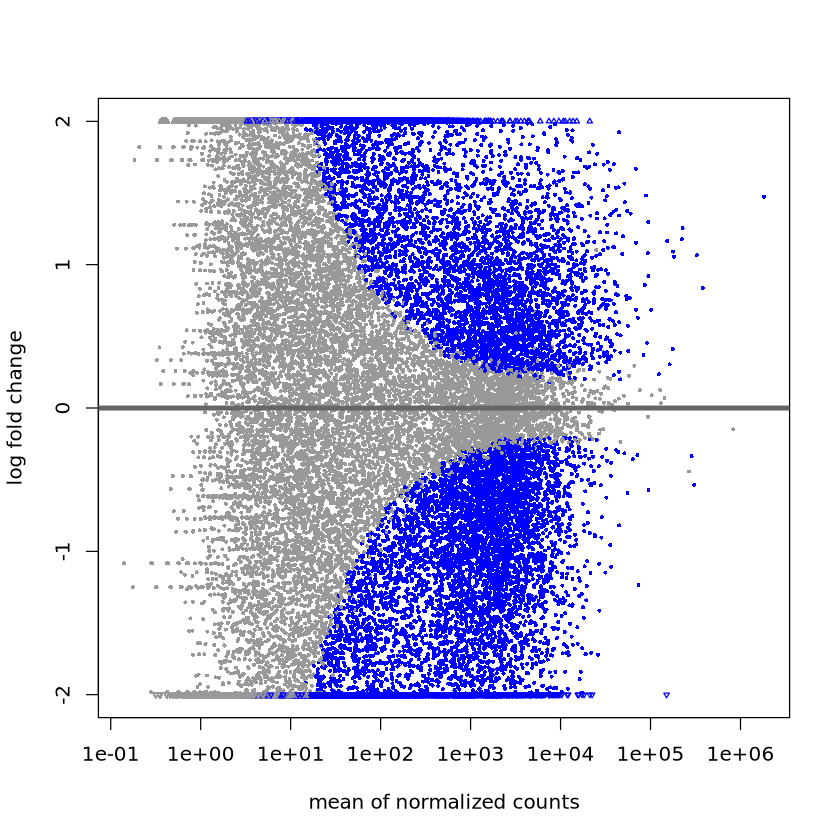

In [102]:
plotMA(res_aux, ylim=c(-2,2))

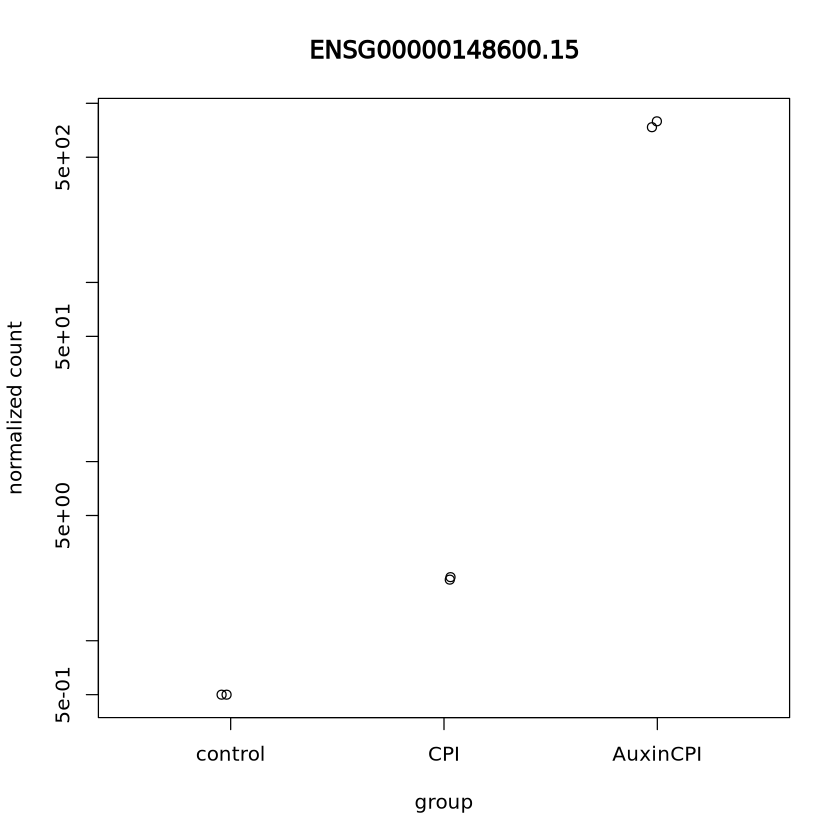

In [103]:
plotCounts(dds, gene=which.max(res_aux$log2FoldChange), intgroup="condition")

In [104]:
#write.csv(as.data.frame(resOrdered), 
#          file="condition_treated_results.csv")

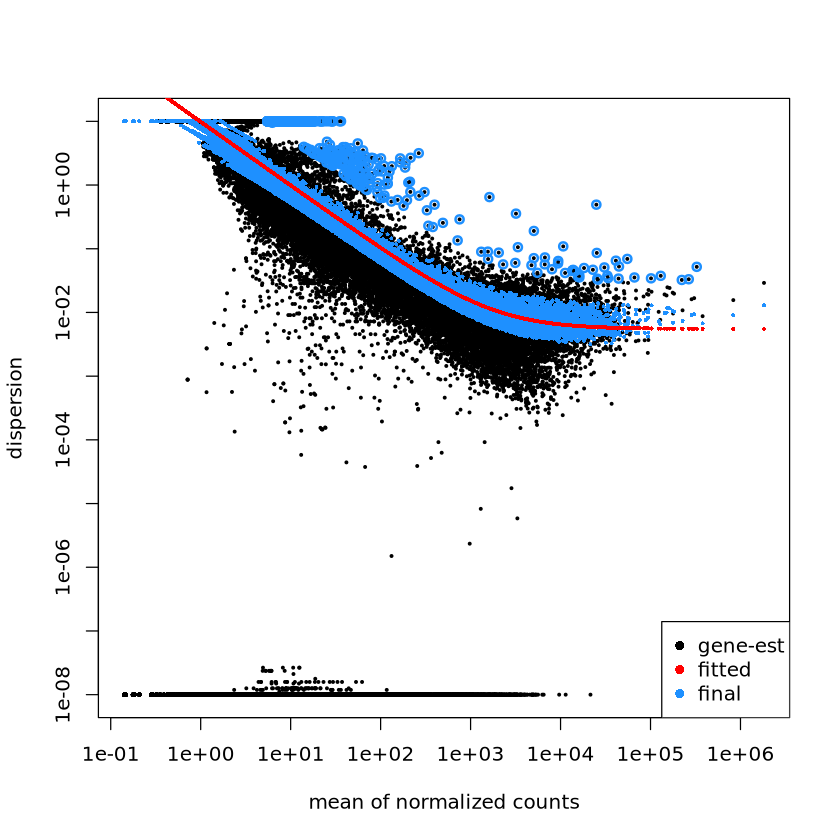

In [105]:
plotDispEsts(dds)

### Transform - VST main

In [106]:
vsd <- vst(dds, blind=FALSE)
head(assay(vsd), 3)

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
ENSG00000290825.2,8.763552,8.763552,8.763552,8.763552,8.853386,8.763552
ENSG00000223972.6,8.763552,8.763552,8.763552,8.763552,8.763552,8.763552
ENSG00000310526.1,9.192389,9.358516,9.942039,9.888528,9.948701,10.029176


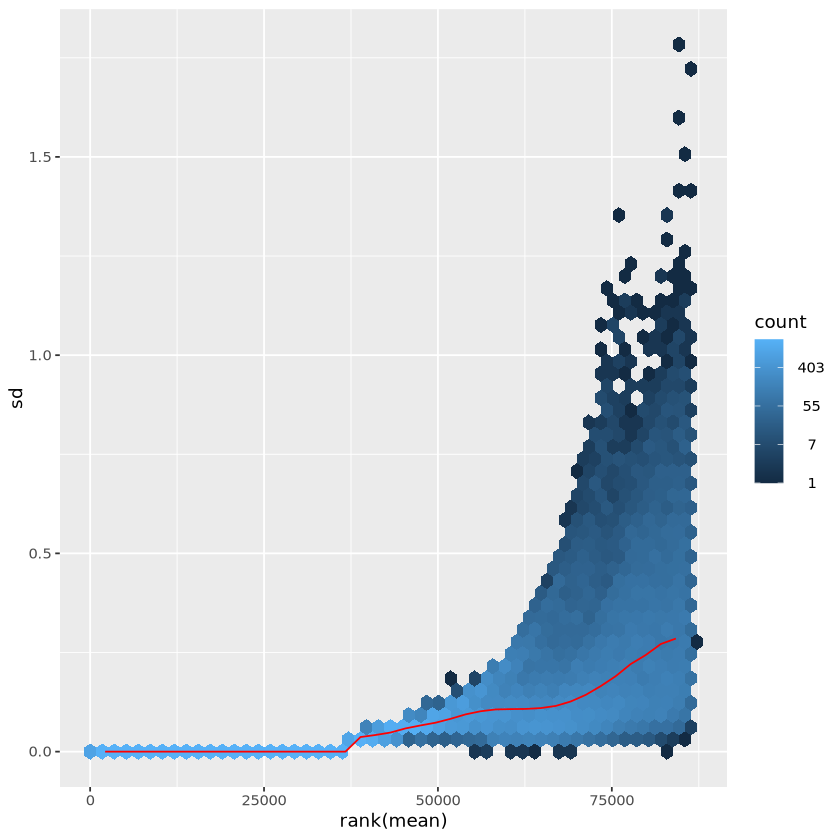

In [107]:
library("vsn")
meanSdPlot(assay(vsd))

### NormTransform

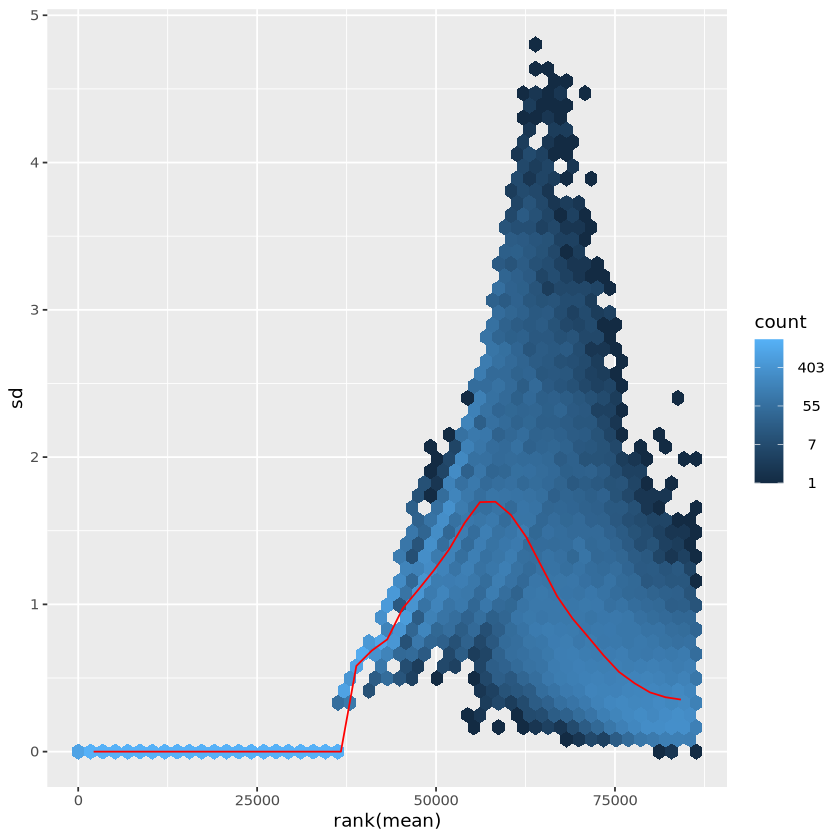

In [108]:
ntd <- normTransform(dds)
meanSdPlot(assay(ntd))

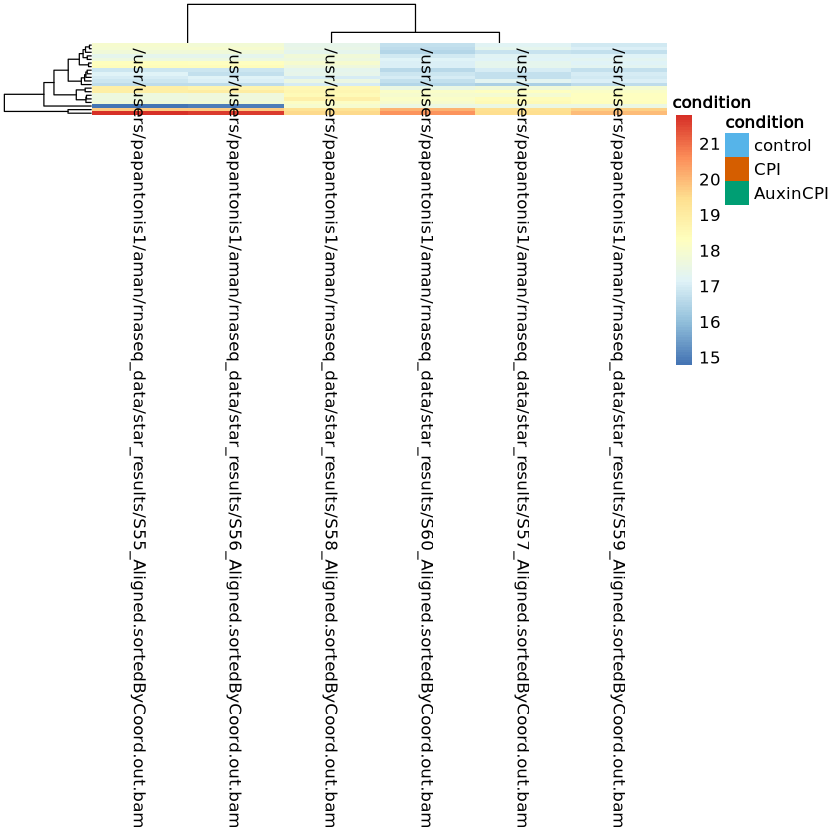

In [109]:
library("pheatmap")

select <- order(rowMeans(counts(dds, normalized=TRUE)), decreasing=TRUE)[1:20]


# Reassign colnames and ensure annotation matches order
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
df <- as.data.frame(colData(dds)[, "condition", drop = FALSE])
rownames(df) <- colnames(vsd)
df$condition <- factor(df$condition, levels = c("control", "CPI", "AuxinCPI"))



# Define annotation colors
ann_colors <- list(
  condition = c("control" = "#56B4E9", "CPI" = "#D55E00", "AuxinCPI" = "#009E73")
)

pheatmap(
  assay(ntd)[select, ],
  cluster_rows = TRUE,
  show_rownames = FALSE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)


In [110]:
all(colnames(assay(vsd)) == rownames(df))

[1] TRUE

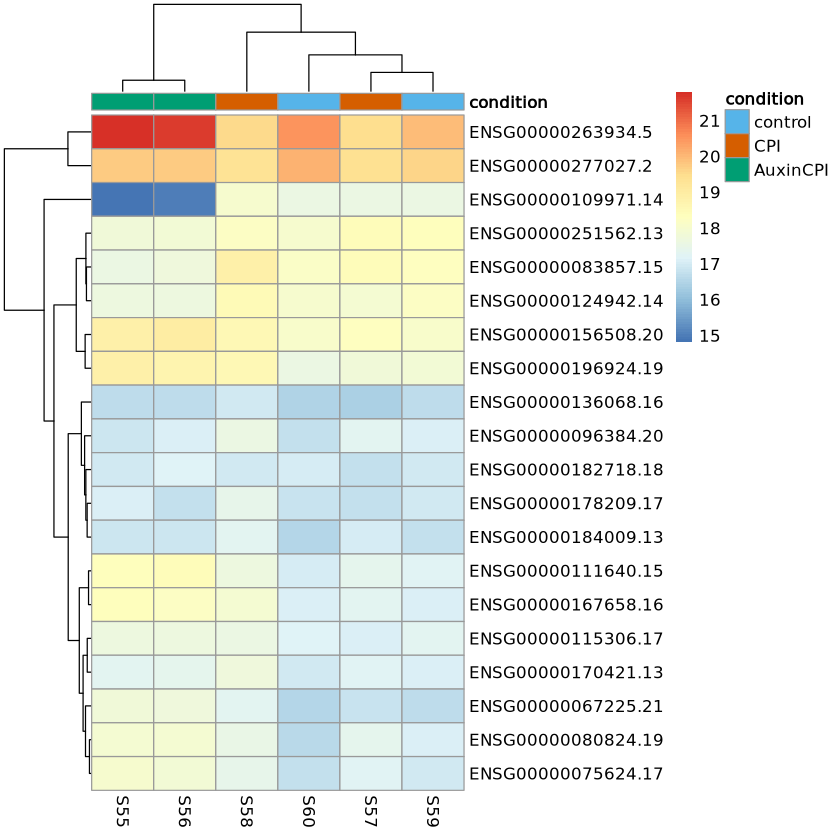

In [111]:
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
pheatmap(
  assay(vsd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)

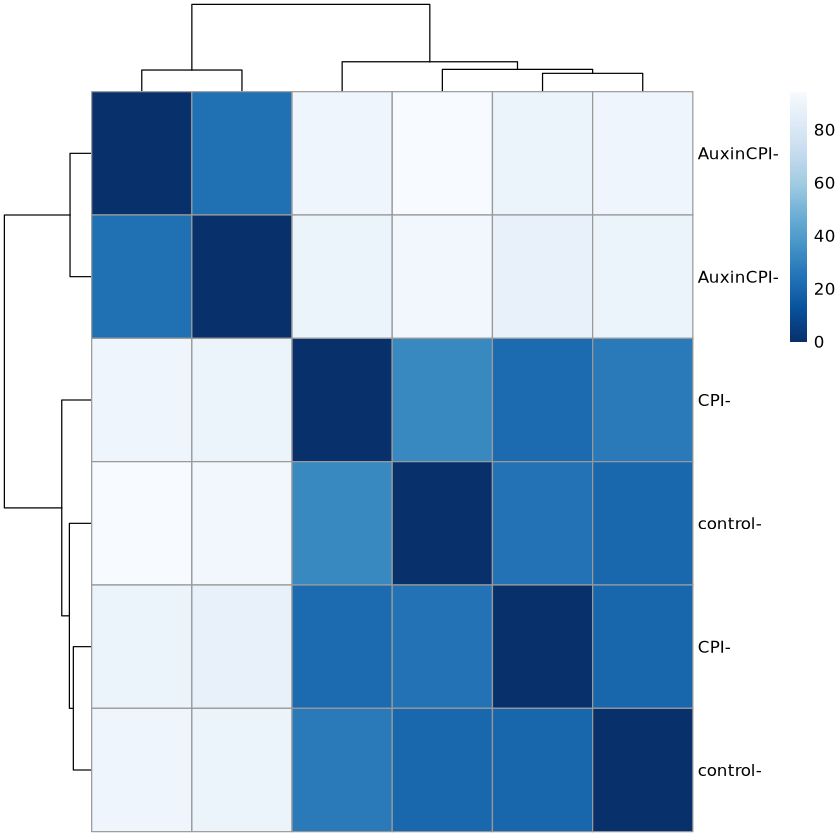

In [112]:
sampleDists <- dist(t(assay(vsd)))
library("RColorBrewer")
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$condition, vsd$type, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

# control and cpi correlated which in a way makes sense biologically

using ntop=500 top features by variance



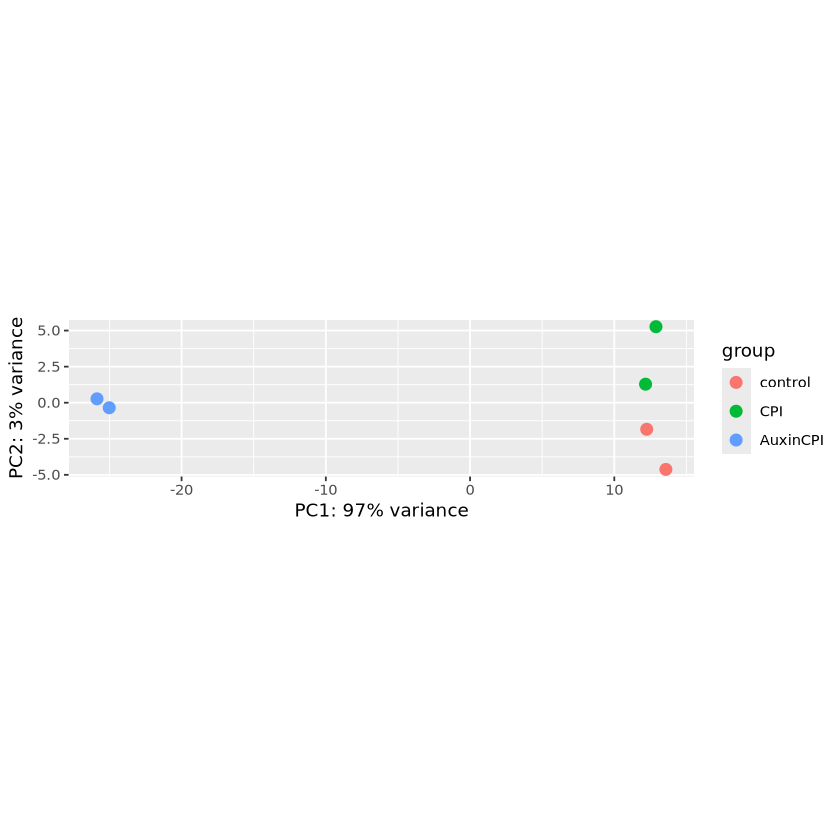

In [113]:
plotPCA(vsd, intgroup=c("condition"))

In [114]:
#options(repr.plot.width = 8, repr.plot.height = 9)
#plotPCA(vsd, intgroup = "condition") + theme(aspect.ratio = 1.5)
pca <- prcomp(t(assay(vsd)))
summary(pca)



Importance of components:
                           PC1      PC2     PC3     PC4     PC5      PC6
Standard deviation     45.4993 10.57308 7.46943 5.94246 5.55822 1.41e-13
Proportion of Variance  0.8985  0.04852 0.02422 0.01533 0.01341 0.00e+00
Cumulative Proportion   0.8985  0.94705 0.97126 0.98659 1.00000 1.00e+00

### Log fold change shrinkage

In [115]:
resultsNames(dds)

[1] "Intercept"                     "condition_CPI_vs_control"     
[3] "condition_AuxinCPI_vs_control"

In [116]:
#resLFC <- lfcShrink(dds, coef="condition_CPI_vs_control", type="apeglm")
#resLFC

resLFC_cpi <- lfcShrink(dds, coef = "condition_CPI_vs_control", type = "apeglm")
resLFC_aux <- lfcShrink(dds, coef = "condition_AuxinCPI_vs_control", type = "apeglm")


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [117]:
# order based on the pval
resOrdered <- res_aux[order(res_aux$pvalue),]
resOrdered

log2 fold change (MLE): condition AuxinCPI vs control 
Wald test p-value: condition AuxinCPI vs control 
DataFrame with 86364 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat       pvalue
                   <numeric>      <numeric> <numeric> <numeric>    <numeric>
ENSG00000168646.14  10309.39       -3.74012  0.114686  -32.6119 2.78016e-233
ENSG00000125378.16  12163.53       -3.10303  0.103316  -30.0343 3.49990e-198
ENSG00000136997.22   8271.63       -4.46111  0.152631  -29.2282 8.51091e-188
ENSG00000128342.5    5384.08       -3.16762  0.113283  -27.9619 4.72527e-172
ENSG00000231721.9   15991.53       -3.36312  0.127647  -26.3471 5.53810e-153
...                      ...            ...       ...       ...          ...
ENSG00000303867.1          0             NA        NA        NA           NA
ENSG00000303902.1          0             NA        NA        NA           NA
ENSG00000306528.1          0             NA        NA        NA           NA
ENSG0000

In [118]:
# filtering with padj < 0.05
sum(res_aux$padj < 0.05, na.rm=TRUE)

[1] 17631

In [119]:
res_raw <- results(dds, contrast = c("condition", "AuxinCPI", "control"))

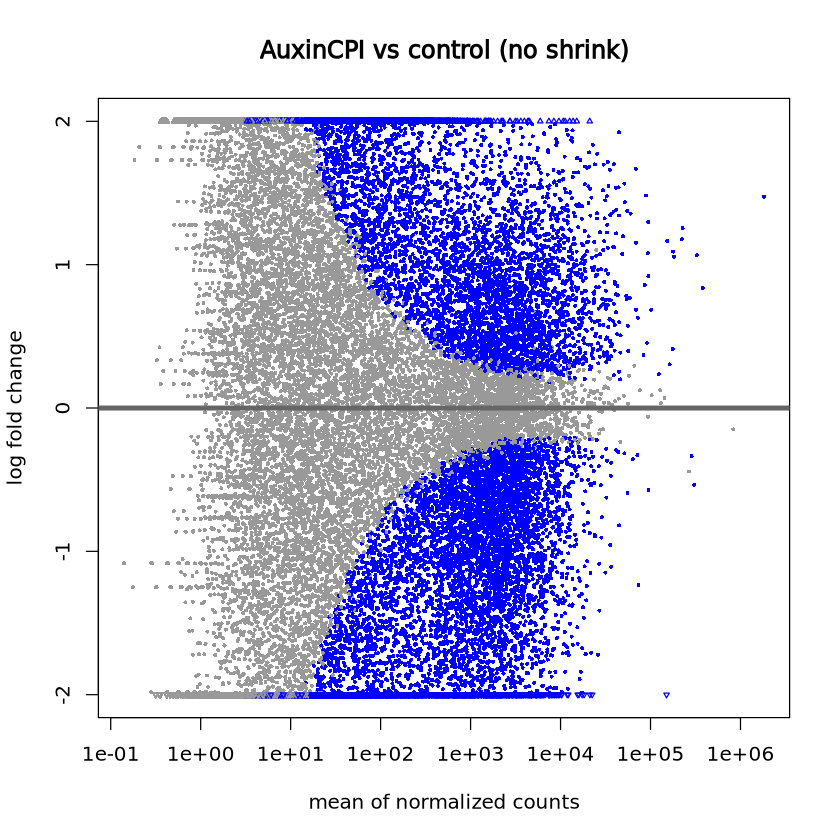

In [120]:
plotMA(res_raw, ylim=c(-2,2), main="AuxinCPI vs control (no shrink)")

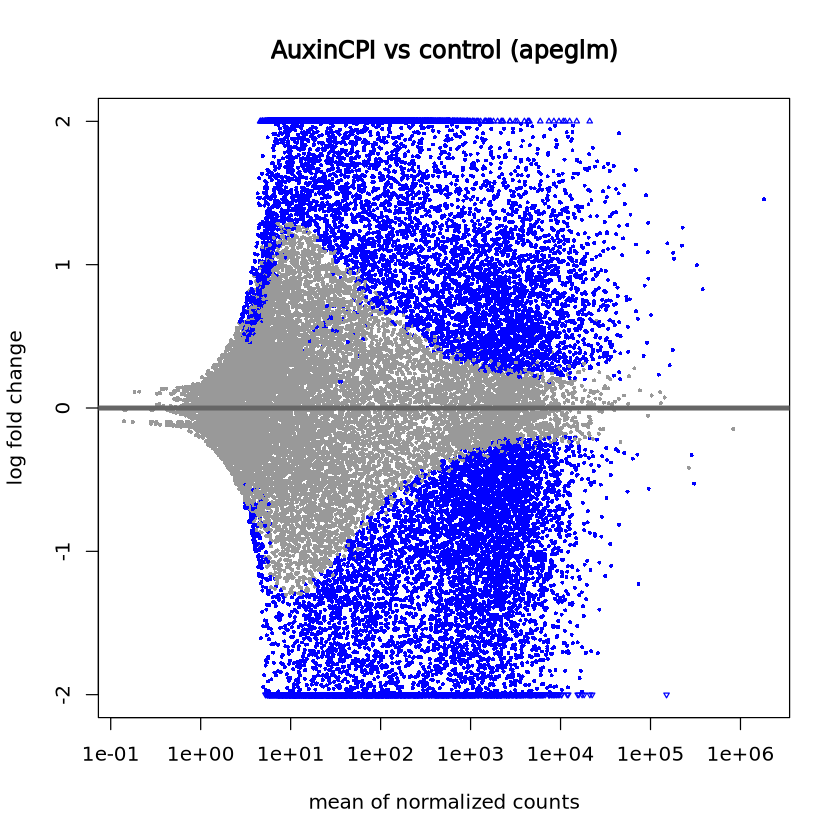

In [121]:
plotMA(resLFC_aux, ylim=c(-2,2), main="AuxinCPI vs control (apeglm)")

In [122]:
mcols(res_aux)$description

[1] "mean of normalized counts for all samples"            
[2] "log2 fold change (MLE): condition AuxinCPI vs control"
[3] "standard error: condition AuxinCPI vs control"        
[4] "Wald statistic: condition AuxinCPI vs control"        
[5] "Wald test p-value: condition AuxinCPI vs control"     
[6] "BH adjusted p-values"

In [123]:
sig_aux <- res_aux[which(res_aux$padj < 0.1), ]

In [124]:
sig_aux

log2 fold change (MLE): condition AuxinCPI vs control 
Wald test p-value: condition AuxinCPI vs control 
DataFrame with 20049 rows and 6 columns
                   baseMean log2FoldChange     lfcSE      stat      pvalue
                  <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000310526.1  227.4475       -2.54296  0.348929  -7.28789 3.14846e-13
ENSG00000310527.1  167.9168       -2.55218  0.333887  -7.64384 2.10834e-14
ENSG00000292994.2   70.6887        2.41702  0.497288   4.86041 1.17143e-06
ENSG00000290385.2   60.7139        1.51758  0.552294   2.74778 6.00011e-03
ENSG00000293331.2   30.6557        4.66578  0.940722   4.95978 7.05720e-07
...                     ...            ...       ...       ...         ...
ENSG00000198886.2  898.0631        2.32029  0.153846  15.08187 2.13137e-51
ENSG00000198786.2 1227.1109        2.35112  0.140586  16.72371 8.80648e-63
ENSG00000198727.2  800.5325        2.44994  0.171394  14.29415 2.37984e-46
ENSG00000210195.2   18.0576   

In [125]:
upregulated <- sig_aux[which(sig_aux$log2FoldChange > 0.6), ]
up_aux <- rownames(upregulated)

In [126]:
downregulated <- sig_aux[which(sig_aux$log2FoldChange < - 0.6), ]
down_aux <- rownames(downregulated)

In [127]:
length(up_aux)

[1] 11073

In [128]:
length(down_aux)

[1] 6697

In [129]:
setwd("/usr/users/papantonis1/aman/rnaseq_data")

In [130]:
#write.table(up_genes, file="upregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)
#write.table(down_genes, file="downregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)

In [131]:
up_df <- data.frame(
  ensembl = rownames(upregulated),
  log2FC = upregulated$log2FoldChange
)

write.table(up_df, file = "upregulated_genes_aux.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [132]:
down_df <- data.frame(
  ensembl = rownames(downregulated),
  log2FC = downregulated$log2FoldChange
)
write.table(down_df, file = "downregulated_genes_aux.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [133]:
# Full result from DESeq2, no filtering by padj
gene_df <- data.frame(
  ensembl = rownames(res),
  log2FC = res$log2FoldChange
)

# Optional: remove NA
gene_df <- na.omit(gene_df)

# Write full ranked gene list for GSEA
write.table(gene_df, file = "ranked_gene_list_aux.txt", sep = "\t", quote = FALSE, row.names = FALSE)

gene_df

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rownames': object 'res' not found


In [ ]:
summary(gene_df)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'summary': object 'gene_df' not found


In [ ]:
up_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000292994.2,2.417023
ENSG00000290385.2,1.517580
ENSG00000293331.2,4.665776
ENSG00000225630.1,2.918697
ENSG00000278791.1,5.820027
ENSG00000248527.1,1.858122
ENSG00000177757.3,7.205570
ENSG00000234711.1,5.437245
ENSG00000296088.1,4.140021


In [ ]:
down_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000310526.1,-2.542957
ENSG00000310527.1,-2.552176
ENSG00000228794.13,-1.217820
ENSG00000272512.1,-1.488130
ENSG00000304119.1,-1.014780
ENSG00000237330.3,-2.659450
ENSG00000207730.3,-2.434462
ENSG00000207607.3,-3.273691
ENSG00000198976.1,-3.445604


Loading required package: ggplot2

Loading required package: ggrepel



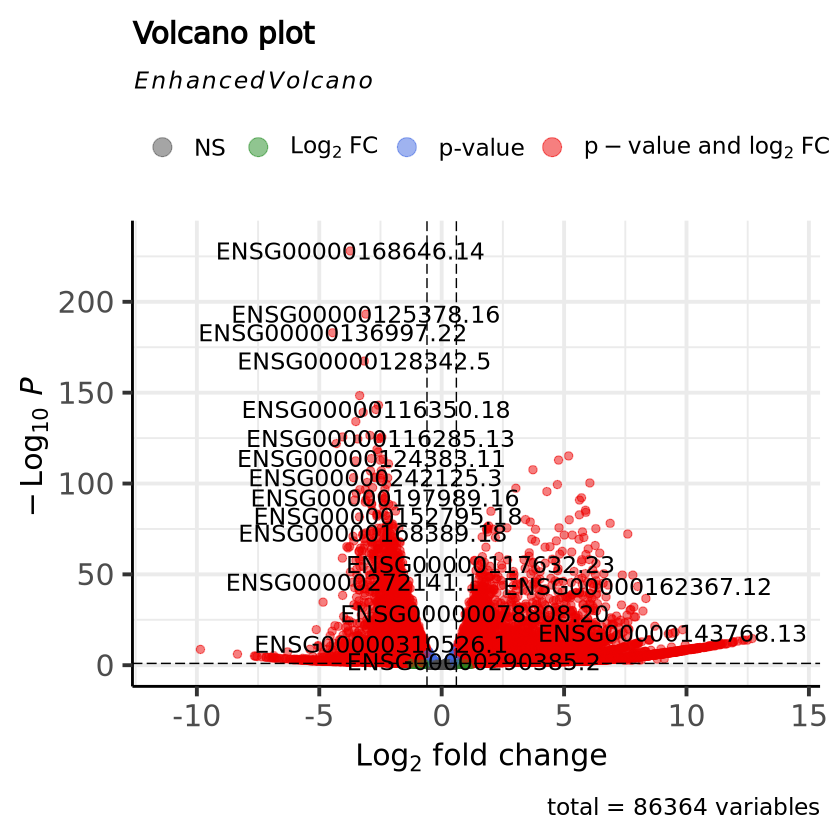

In [ ]:
library(EnhancedVolcano)
EnhancedVolcano(resLFC_aux,
  lab = rownames(resLFC_aux),
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.1,
  FCcutoff = 0.6)

# resLFC used as it is the shrunk one

### The next step is to display the gene names instead of the ensembl ids

In [ ]:
# todo

In [ ]:
# Skip 'version="devel"' which pulls the latest (3.22, needs R 4.5)
#BiocManager::install(version = "3.18")
#BiocManager::install("biomaRt")


In [ ]:
library(biomaRt)

In [ ]:
# Set up biomart
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Remove version suffix (.10, .11 etc.)
ids <- gsub("\\..*", "", rownames(resLFC_aux))

# Query gene names
annot <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = ids,
  mart = mart
)

In [ ]:
annot

ensembl_gene_id,hgnc_symbol
<chr>,<chr>
ENSG00000000938,FGR
ENSG00000001460,STPG1
ENSG00000001461,NIPAL3
ENSG00000004455,AK2
ENSG00000004487,KDM1A
ENSG00000006555,TTC22
ENSG00000007341,ST7L
ENSG00000007923,DNAJC11
ENSG00000007968,E2F2


In [ ]:
# Merge with result table
resLFC_aux$ensembl_id <- gsub("\\..*", "", rownames(resLFC_aux))
res_annot <- merge(as.data.frame(resLFC_aux), annot, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Set gene symbols as rownames (fallback to Ensembl if missing)
res_annot$label <- ifelse(res_annot$hgnc_symbol == "", res_annot$ensembl_id, res_annot$hgnc_symbol)

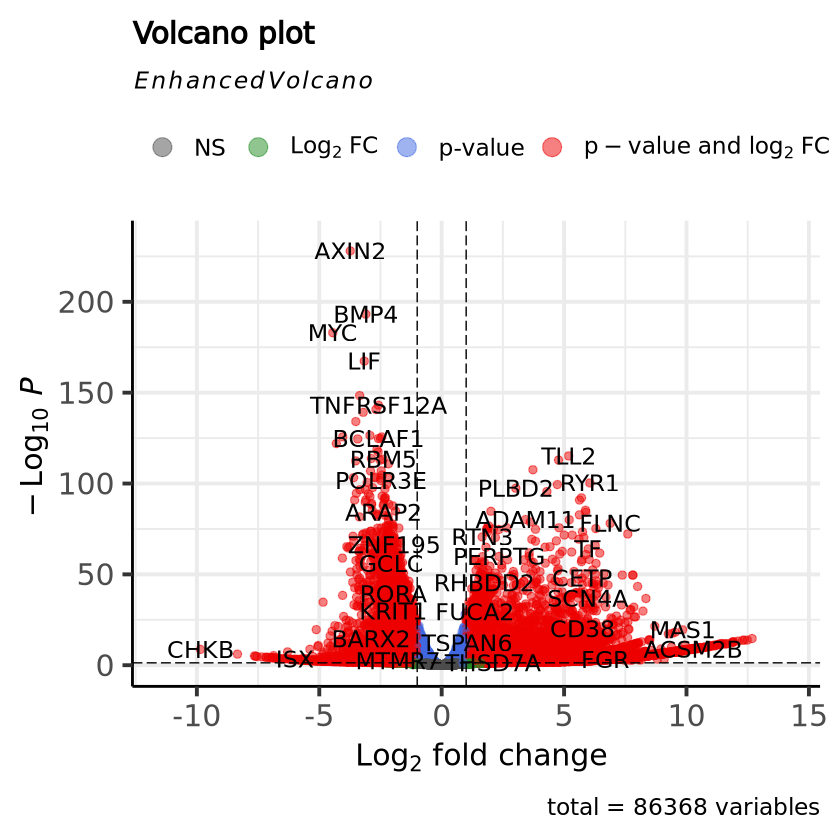

In [ ]:
EnhancedVolcano(
  res_annot,
  lab = res_annot$label,
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 1
)


In [ ]:
head(up_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000292994.2,2.417023
2,ENSG00000290385.2,1.517580
3,ENSG00000293331.2,4.665776
4,ENSG00000225630.1,2.918697
5,ENSG00000278791.1,5.820027
6,ENSG00000248527.1,1.858122


In [ ]:
head(down_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000310526.1,-2.542957
2,ENSG00000310527.1,-2.552176
3,ENSG00000228794.13,-1.217820
4,ENSG00000272512.1,-1.488130
5,ENSG00000304119.1,-1.014780
6,ENSG00000237330.3,-2.659450


In [ ]:
# Load biomaRt
library(biomaRt)

# Strip version suffixes
up_df$ensembl_id <- sub("\\..*", "", up_df$ensembl)
down_df$ensembl_id <- sub("\\..*", "", down_df$ensembl)

# Connect to Ensembl
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Get gene symbols
gene_info <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = unique(c(up_df$ensembl_id, down_df$ensembl_id)),
  mart = mart
)

# Merge gene symbols with up_df
up_df_annot <- merge(up_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Merge gene symbols with down_df
down_df_annot <- merge(down_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

In [ ]:
# Replace missing hgnc_symbol with ensembl_id
up_df_annot$hgnc_symbol <- ifelse(
  up_df_annot$hgnc_symbol == "" | is.na(up_df_annot$hgnc_symbol),
  up_df_annot$ensembl_id,
  up_df_annot$hgnc_symbol
)

down_df_annot$hgnc_symbol <- ifelse(
  down_df_annot$hgnc_symbol == "" | is.na(down_df_annot$hgnc_symbol),
  down_df_annot$ensembl_id,
  down_df_annot$hgnc_symbol
)


In [ ]:
up_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000000003,ENSG00000000003.16,1.045577,TSPAN6
ENSG00000000938,ENSG00000000938.13,7.432205,FGR
ENSG00000001036,ENSG00000001036.14,1.360148,FUCA2
ENSG00000001630,ENSG00000001630.18,1.600279,CYP51A1
ENSG00000002726,ENSG00000002726.21,2.433086,AOC1
ENSG00000004468,ENSG00000004468.13,5.858842,CD38
ENSG00000004777,ENSG00000004777.19,3.000973,ARHGAP33
ENSG00000004809,ENSG00000004809.14,4.926831,SLC22A16
ENSG00000004939,ENSG00000004939.16,2.937354,SLC4A1


In [ ]:
down_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000000457,ENSG00000000457.14,-1.277355,SCYL3
ENSG00000001084,ENSG00000001084.13,-2.075514,GCLC
ENSG00000001631,ENSG00000001631.17,-1.999575,KRIT1
ENSG00000002587,ENSG00000002587.10,-1.823042,HS3ST1
ENSG00000002745,ENSG00000002745.13,-2.666805,WNT16
ENSG00000003393,ENSG00000003393.16,-1.124815,ALS2
ENSG00000003756,ENSG00000003756.17,-2.397816,RBM5
ENSG00000003987,ENSG00000003987.14,-2.051907,MTMR7
ENSG00000004660,ENSG00000004660.15,-1.488043,CAMKK1


In [ ]:
write.table(up_df_annot, file = "upregulated_genes_deseq_auxincpi.txt", sep = "\t", quote = FALSE, row.names = FALSE)
write.table(down_df_annot, file = "downregulated_genes_deseq_auxincpi.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [ ]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)
run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "hgnc_symbol") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.1,
    readable      = TRUE
  )

  return(ego)
}



clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:biomaRt’:

    select


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select




Warning message:
“package ‘readr’ was built under R version 4.4.3”


In [ ]:
ego_result_up_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq_auxincpi.txt")

# View results
as.data.frame(ego_result_up_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0007156,GO:0007156,homophilic cell adhesion via plasma membrane adhesion molecules,89/3480,168/18870,5.406869e-24,3.307382e-20,2.716525e-20,AMIGO1/CADM1/CADM4/CD84/CDH1/CDH13/CDH15/CDH16/CDH17/CDH22/CDH24/CDH3/CDHR1/CDHR2/CDHR4/CEACAM5/CEACAM6/CELSR2/CELSR3/CLSTN1/CNTN2/DCHS1/DCHS2/DSC3/DSG2/ESAM/FAT2/HMCN1/IGSF11/L1CAM/MYPN/NECTIN2/NECTIN3/NEXN/PALLD/PCDH1/PCDH12/PCDH19/PCDHA1/PCDHA2/PCDHA4/PCDHA5/PCDHA6/PCDHA7/PCDHA8/PCDHA9/PCDHB1/PCDHB11/PCDHB12/PCDHB13/PCDHB2/PCDHB3/PCDHB5/PCDHB8/PCDHGA1/PCDHGA2/PTK7/PTPN23/PTPRM/TENM3/PCDHA10/PCDHA11/PCDHA12/PCDHA13/PCDHA3/PCDHAC1/PCDHAC2/PCDHB16/PCDHGA10/PCDHGA11/PCDHGA12/PCDHGA3/PCDHGA4/PCDHGA5/PCDHGA6/PCDHGA7/PCDHGA8/PCDHGA9/PCDHGB1/PCDHGB2/PCDHGB3/PCDHGB4/PCDHGB5/PCDHGB6/PCDHGB7/PCDHGC3/PCDHGC4/PCDHGC5/PECAM1,89
GO:0098742,GO:0098742,cell-cell adhesion via plasma-membrane adhesion molecules,112/3480,279/18870,1.516716e-17,4.638876e-14,3.810150e-14,ADIPOQ/ALCAM/AMIGO1/APOA1/CADM1/CADM4/CD177/CD84/CDH1/CDH13/CDH15/CDH16/CDH17/CDH22/CDH24/CDH3/CDHR1/CDHR2/CDHR4/CEACAM5/CEACAM6/CELSR2/CELSR3/CLDN11/CLDN19/CLDN22/CLSTN1/CNTN2/CRB1/CRTAM/DCHS1/DCHS2/DSC3/DSG2/ESAM/FAT2/FXYD5/GPC4/HMCN1/IGSF11/IL10/ITGAL/ITGAM/ITGB2/JAML/L1CAM/MYPN/NECTIN2/NECTIN3/NEXN/PALLD/PCDH1/PCDH12/PCDH19/PCDHA1/PCDHA2/PCDHA4/PCDHA5/PCDHA6/PCDHA7/PCDHA8/PCDHA9/PCDHB1/PCDHB11/PCDHB12/PCDHB13/PCDHB2/PCDHB3/PCDHB5/PCDHB8/PCDHGA1/PCDHGA2/PTK7/PTPN23/PTPRF/PTPRM/PTPRS/SELE/SELP/TENM3/UMOD/VCAM1/PCDHA10/PCDHA11/PCDHA12/PCDHA13/PCDHA3/PCDHAC1/PCDHAC2/PCDHB16/PCDHGA10/PCDHGA11/PCDHGA12/PCDHGA3/PCDHGA4/PCDHGA5/PCDHGA6/PCDHGA7/PCDHGA8/PCDHGA9/PCDHGB1/PCDHGB2/PCDHGB3/PCDHGB4/PCDHGB5/PCDHGB6/PCDHGB7/PCDHGC3/PCDHGC4/PCDHGC5/PECAM1/SCARF2,112
GO:0030198,GO:0030198,extracellular matrix organization,119/3480,321/18870,1.799746e-15,3.585065e-12,2.944601e-12,ABI3BP/ADAM15/ADAMTS12/ADAMTS13/ADAMTS14/ADAMTS17/ADAMTS20/ADAMTS6/ADAMTS9/ADAMTSL1/ADAMTSL4/AEBP1/AGT/ANTXR1/APLP1/APP/B4GALT1/C6orf15/CCDC80/CHADL/COL10A1/COL12A1/COL17A1/COL1A1/COL23A1/COL28A1/COL2A1/COL3A1/COL4A3/COL4A4/COL5A1/COL5A2/COL5A3/COL8A2/COL9A1/COLGALT1/COLGALT2/COLQ/COMP/CRTAP/CST3/CTSS/CTSV/CYP1B1/DAG1/DDR1/DDR2/DMP1/ECM2/EGFLAM/ELN/EMILIN1/ENG/FAP/FBLN1/FBLN5/FGFR4/FKBP10/FLOT1/FURIN/GAS6/GFAP/GREM1/HAPLN2/HAS3/HMCN1/IHH/IMPG2/LAMB2/LOXL4/MATN2/MATN3/MATN4/MELTF/MMP11/MMP13/MMP14/MMP17/MMP19/MMP21/MYF5/MYH11/NID1/NPHS1/NPNT/OLFML2B/OTOL1/P3H4/P4HA1/PAPLN/PBXIP1/PLOD3/PRDX4/PRSS1/PTX3/QSOX1/RAMP2/RECK/SERPINF2/SMOC1/SPINT1/SPINT2/SPOCK2/SULF2/TGFBI/TIE1/TLL2/TMEM38B/TNR/TNXB/VIT/VTN/VWA1/ITGB3/MIA/MMP12/MMP28/PRSS2/SCX,119
GO:0043062,GO:0043062,extracellular structure organization,119/3480,322/18870,2.344329e-15,3.585065e-12,2.944601e-12,ABI3BP/ADAM15/ADAMTS12/ADAMTS13/ADAMTS14/ADAMTS17/ADAMTS20/ADAMTS6/ADAMTS9/ADAMTSL1/ADAMTSL4/AEBP1/AGT/ANTXR1/APLP1/APP/B4GALT1/C6orf15/CCDC80/CHADL/COL10A1/COL12A1/COL17A1/COL1A1/COL23A1/COL28A1/COL2A1/COL3A1/COL4A3/COL4A4/COL5A1/COL5A2/COL5A3/COL8A2/COL9A1/COLGALT1/COLGALT2/COLQ/COMP/CRTAP/CST3/CTSS/CTSV/CYP1B1/DAG1/DDR1/DDR2/DMP1/ECM2/EGFLAM/ELN/EMILIN1/ENG/FAP/FBLN1/FBLN5/FGFR4/FKBP10/FLOT1/FURIN/GAS6/GFAP/GREM1/HAPLN2/HAS3/HMCN1/IHH/IMPG2/LAMB2/LOXL4/MATN2/MATN3/MATN4/MELTF/MMP11/MMP13/MMP14/MMP17/MMP19/MMP21/MYF5/MYH11/NID1/NPHS1/NPNT/OLFML2B/OTOL1/P3H4/P4HA1/PAPLN/PBXIP1/PLOD3/PRDX4/PRSS1/PTX3/QSOX1/RAMP2/RECK/SERPINF2/SMOC1/SPINT1/SPINT2/SPOCK2/SULF2/TGFBI/TIE1/TLL2/TMEM38B/TNR/TNXB/VIT/VTN/VWA1/ITGB3/MIA/MMP12/MMP28/PRSS2/SCX,119
GO:0045229,GO:0045229,external encapsulating structure organization,119/3480,323/18870,3.048153e-15,3.729111e-12,3.062913e-12,ABI3BP/ADAM15/ADAMTS12/ADAMTS13/ADAMTS14/ADAMTS17/ADAMTS20/ADAMTS6/ADAMTS9/ADAMTSL1/ADAMTSL4/AEBP1/AGT/ANTXR1/APLP1/APP/B4GALT1/C6orf15/CCDC80/CHADL/COL10A1/COL12A1/COL17A1/COL1A1/COL23A1/COL28A1/COL2A1/COL3A1/COL4A3/COL4A4/COL5A1/COL5A2/COL5A3/COL8A2/COL9A1/COLGALT1/COLGALT2/COLQ/COMP/CRTAP/CST3/CTSS/CTSV/CYP1B1/DAG1/DDR1/DDR2/DMP1/ECM2/EGFLAM/ELN/E

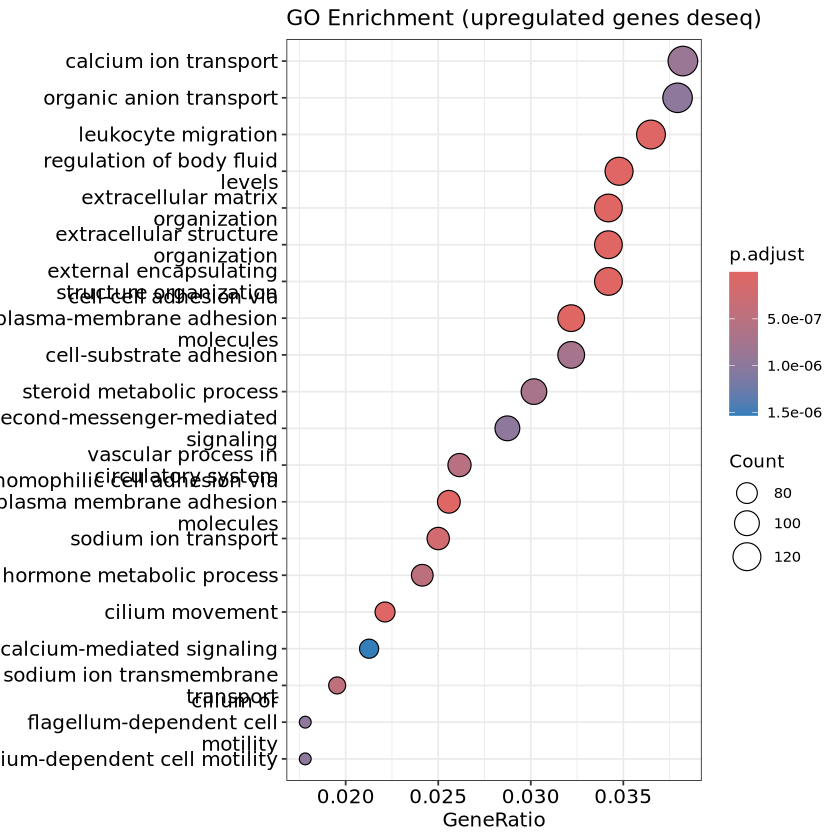

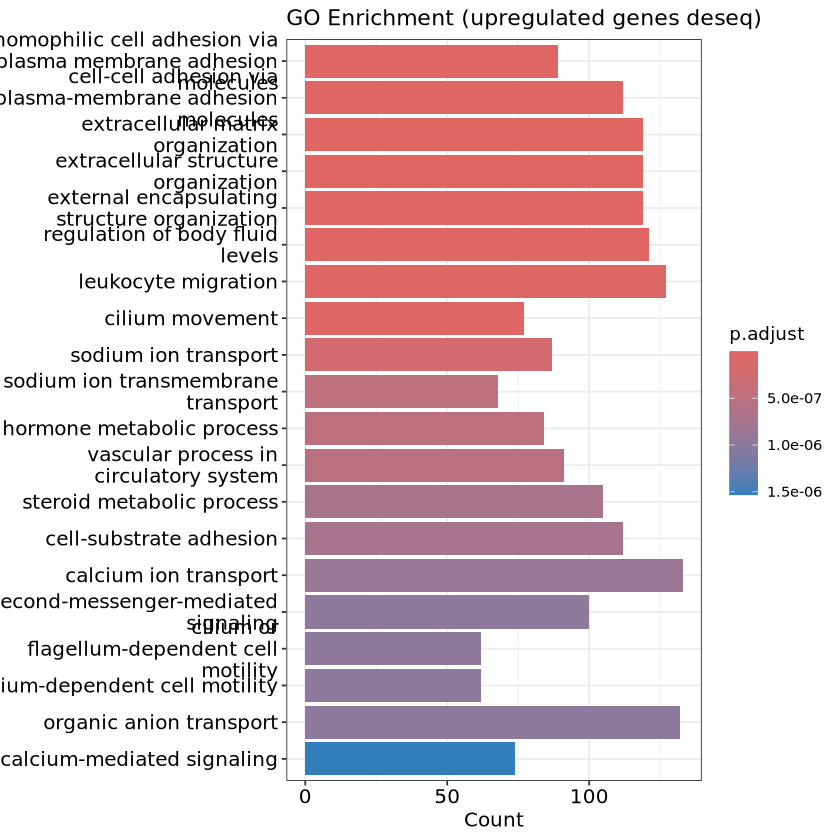

In [ ]:
dotplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (upregulated genes deseq)")
barplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (upregulated genes deseq)")

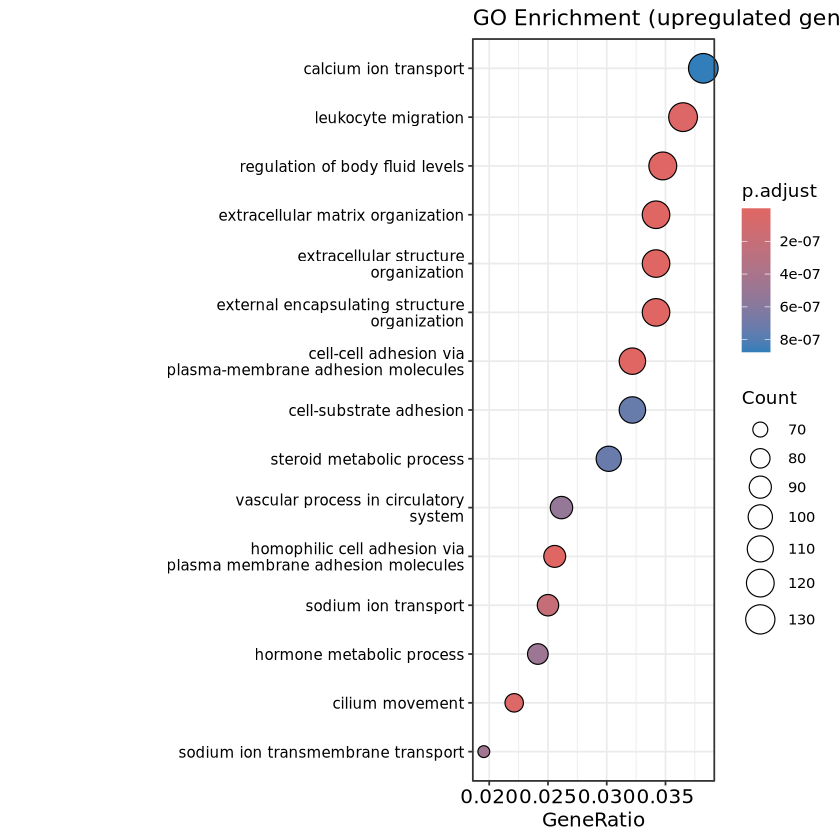

In [ ]:
library(enrichplot)
library(ggplot2)
library(stringr)

p <- dotplot(
  ego_result_up_deseq,
  showCategory = 15,
  title = "GO Enrichment (upregulated genes deseq)",
  label_format = 35
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")  # enlarge left margin
  ) +
  coord_cartesian(clip = "off")

p


In [ ]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)
run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "hgnc_symbol") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.2,
    readable      = TRUE
  )

  return(ego)
}

In [ ]:
ego_result_down_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq_auxincpi.txt")

# View results
as.data.frame(ego_result_down_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0034470,GO:0034470,ncRNA processing,151/2437,439/18870,9.934675e-32,5.774033e-28,5.230868e-28,ALKBH1/ALKBH8/ANKRD16/BMP4/BRIX1/BYSL/C2orf49/CDK5RAP1/CHD7/DCAF13/DDX10/DDX5/DDX51/DGCR8/DHX37/DICER1/DIMT1/DKC1/DUS2/ELP6/EMG1/ESF1/EXOSC10/EXOSC2/EXOSC4/EXOSC7/EXOSC8/EXOSC9/FAM98A/FRG1/FTSJ3/GAR1/GEMIN4/GTPBP4/H19/IMP3/IMP4/INTS10/INTS12/INTS13/INTS6L/INTS7/KTI12/LARP7/LCMT2/LYAR/MAK16/METTL1/METTL18/METTL3/METTL5/MPHOSPH10/MPHOSPH6/MRM3/MRPL44/MTREX/NGDN/NIFK/NOL10/NOL11/NOL6/NOL8/NOP2/NOP56/NOP58/NSUN5/OSGEP/PDCD11/PES1/PLD6/POP1/POP7/PPAN/PRKRA/PUM1/PUM2/PUS1/PUS3/PWP1/QTRT2/RBFA/RCL1/REXO4/RIOK1/RIOK2/RNASEL/RPF1/RPP38/RPP40/RPUSD1/RPUSD2/RPUSD4/RRP1/RRP12/RRP15/RRP9/RRS1/SHQ1/SIRT7/SMAD1/SRSF3/TARBP1/TENT4B/TFB1M/TFB2M/THADA/THUMPD1/THUMPD2/TOE1/TP53RK/TRIT1/TRMO/TRMT1/TRMT10A/TRMT10B/TRMT10C/TRMT11/TRMT12/TRMT13/TRMT2A/TRMT5/TRMT6/TRMT61B/TRNT1/TRPT1/TSEN2/TSEN54/TYW3/UTP11/UTP14A/UTP15/UTP18/UTP20/UTP23/UTP25/UTP3/WDR3/WDR36/WDR4/WDR43/WDR74/WDR75/YRDC/YTHDF2/ZNHIT6/DDX3X/DDX47/FDXACB1/HOXB-AS3/NSUN5P2/RRP7BP,151
GO:0042254,GO:0042254,ribosome biogenesis,122/2437,325/18870,7.550545e-30,2.194188e-26,1.987780e-26,AFG2B/BRIX1/BYSL/C1orf131/CHD7/DCAF13/DDX10/DDX28/DDX31/DDX51/DHX37/DIMT1/DKC1/DNTTIP2/EFL1/EMG1/ESF1/EXOSC10/EXOSC2/EXOSC4/EXOSC7/EXOSC8/EXOSC9/FASTKD2/FRG1/FTSJ3/GAR1/GEMIN4/GNL2/GRWD1/GTPBP4/HEATR3/IMP3/IMP4/ISG20L2/LTV1/LYAR/MAK16/MDN1/METTL18/METTL5/MPHOSPH10/MPHOSPH6/MRM3/MRPL44/MRPS2/MTERF3/MTREX/MYBBP1A/NGDN/NIFK/NLE1/NOL10/NOL11/NOL6/NOL8/NOM1/NOP16/NOP2/NOP56/NOP58/NSUN5/PAK1IP1/PDCD11/PES1/PNO1/POP7/PPAN/PWP1/RBFA/RBIS/RCL1/REXO4/RIOK1/RIOK2/RIOX2/RNASEL/RPF1/RPP38/RPP40/RPS19BP1/RPUSD1/RPUSD2/RPUSD4/RRP1/RRP12/RRP15/RRP9/RRS1/SHQ1/SIRT7/SURF6/TENT4B/TFB1M/TFB2M/TMA16/TRMT61B/TSC1/URB2/USP16/UTP11/UTP14A/UTP15/UTP18/UTP20/UTP23/UTP25/UTP3/WDR3/WDR36/WDR43/WDR74/WDR75/YTHDF2/ZNHIT6/AATF/DDX3X/DDX47/FDXACB1/NSUN5P2/RRP7BP/ZNF658,122
GO:0016072,GO:0016072,rRNA metabolic process,100/2437,264/18870,5.021695e-25,9.728698e-22,8.813516e-22,BRF1/BRIX1/BYSL/CHD7/DCAF13/DDX10/DDX51/DEDD/DHX37/DIMT1/DKC1/EMG1/ESF1/EXOSC10/EXOSC2/EXOSC4/EXOSC7/EXOSC8/EXOSC9/FRG1/FTSJ3/GAR1/GEMIN4/GTF3C4/GTPBP4/IMP3/IMP4/LYAR/MAK16/METTL18/METTL5/MPHOSPH10/MPHOSPH6/MRM3/MRPL44/MTREX/NGDN/NIFK/NOL10/NOL11/NOL6/NOL8/NOP2/NOP56/NOP58/NSUN5/PDCD11/PELO/PES1/POLR1B/POLR1G/POP7/PPAN/PWP1/RBFA/RCL1/REXO4/RIOK1/RIOK2/RNASEL/RPF1/RPP38/RPP40/RPUSD1/RPUSD2/RPUSD4/RRP1/RRP12/RRP15/RRP9/RRS1/SHQ1/SIRT7/SPIN1/TAF1B/TENT4B/TFB1M/TFB2M/TRMT61B/UTP11/UTP14A/UTP15/UTP18/UTP20/UTP23/UTP25/UTP3/WDR3/WDR36/WDR43/WDR74/WDR75/YTHDF2/ZCCHC7/ZNHIT6/DDX47/ERCC6/FDXACB1/NSUN5P2/RRP7BP,100
GO:0006364,GO:0006364,rRNA processing,90/2437,225/18870,1.294885e-24,1.881468e-21,1.704478e-21,BRIX1/BYSL/CHD7/DCAF13/DDX10/DDX51/DHX37/DIMT1/DKC1/EMG1/ESF1/EXOSC10/EXOSC2/EXOSC4/EXOSC7/EXOSC8/EXOSC9/FRG1/FTSJ3/GAR1/GEMIN4/GTPBP4/IMP3/IMP4/LYAR/MAK16/METTL18/METTL5/MPHOSPH10/MPHOSPH6/MRM3/MRPL44/MTREX/NGDN/NIFK/NOL10/NOL11/NOL6/NOL8/NOP2/NOP56/NOP58/NSUN5/PDCD11/PES1/POP7/PPAN/PWP1/RBFA/RCL1/REXO4/RIOK1/RIOK2/RNASEL/RPF1/RPP38/RPP40/RPUSD1/RPUSD2/RPUSD4/RRP1/RRP12/RRP15/RRP9/RRS1/SHQ1/SIRT7/TENT4B/TFB1M/TFB2M/TRMT61B/UTP11/UTP14A/UTP15/UTP18/UTP20/UTP23/UTP25/UTP3/WDR3/WDR36/WDR43/WDR74/WDR75/YTHDF2/ZNHIT6/DDX47/FDXACB1/NSUN5P2/RRP7BP,90
GO:0008380,GO:0008380,RNA splicing,123/2437,478/18870,1.523607e-14,1.771040e-11,1.604438e-11,ACIN1/ARL6IP4/ARMC7/ATXN7/ATXN7L3/C2orf49/CCNL1/CDK13/CENATAC/CIR1/CIRBP/CLK4/COIL/CWC15/CWC22/DDX20/DDX5/DHX15/DNAJC17/ESRP2/FAM98A/FRG1/GCFC2/GEMIN2/GEMIN4/GEMIN5/GEMIN6/GEMIN7/HNRNPF/HSPA8/IVNS1ABP/IWS1/LARP7/LSM1/LUC7L/LUC7L2/LUC7L3/METTL3/METTL4/MPHOSPH10/MTREX/NRDE2/NSRP1/PHF5A/PIK3R1/PNN/PPIG/PPP4R2/PPWD1/PQBP1/PRPF4B/PRPF3/PRPF38B/PRPF39/PTBP2/PUF60/PUS1/RBM12B/RBM17/RBM22/RBM38/RBM39/RBM4B/RBM5/RBM7/REST/RNU5D-1/RNVU1-15/RP9/RPUSD4/RSRP1/SART3/SCNM1/SFSWAP/SGF29/SLC38A2/SMN1/SMN2/SMNDC1/SNRNP35/SNRPA1/SNW1/SREK1/SRSF1/

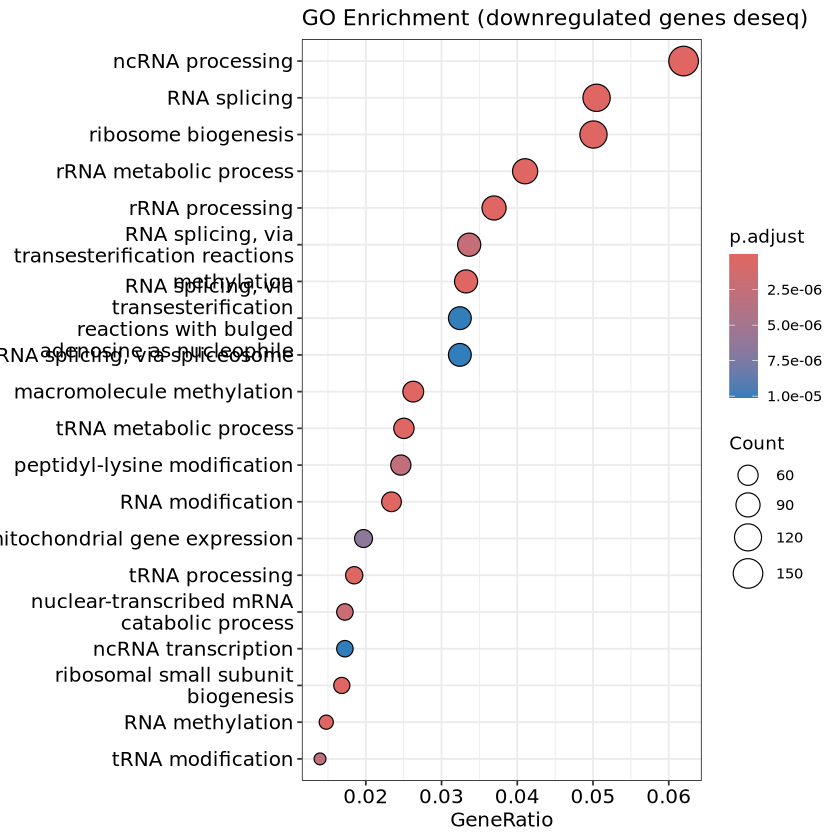

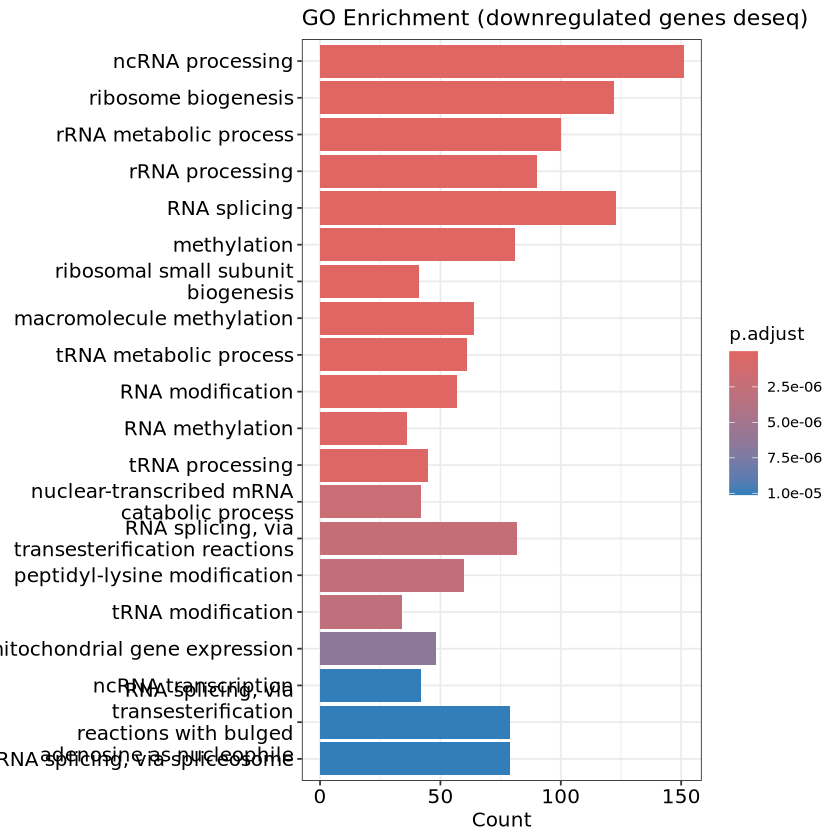

In [ ]:
dotplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (downregulated genes deseq)")
barplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (downregulated genes deseq)")

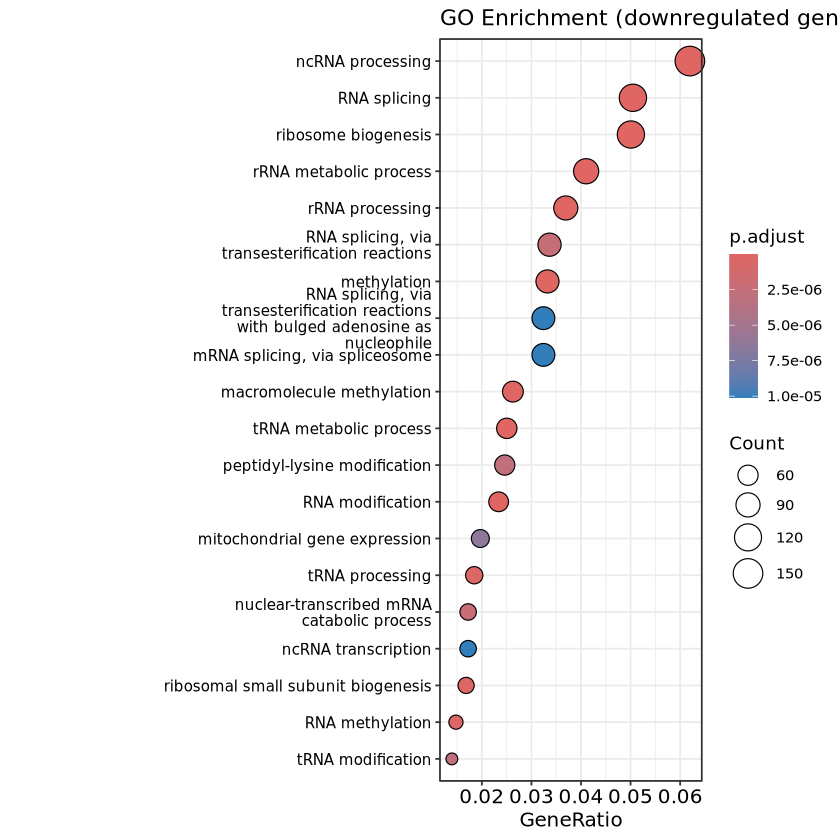

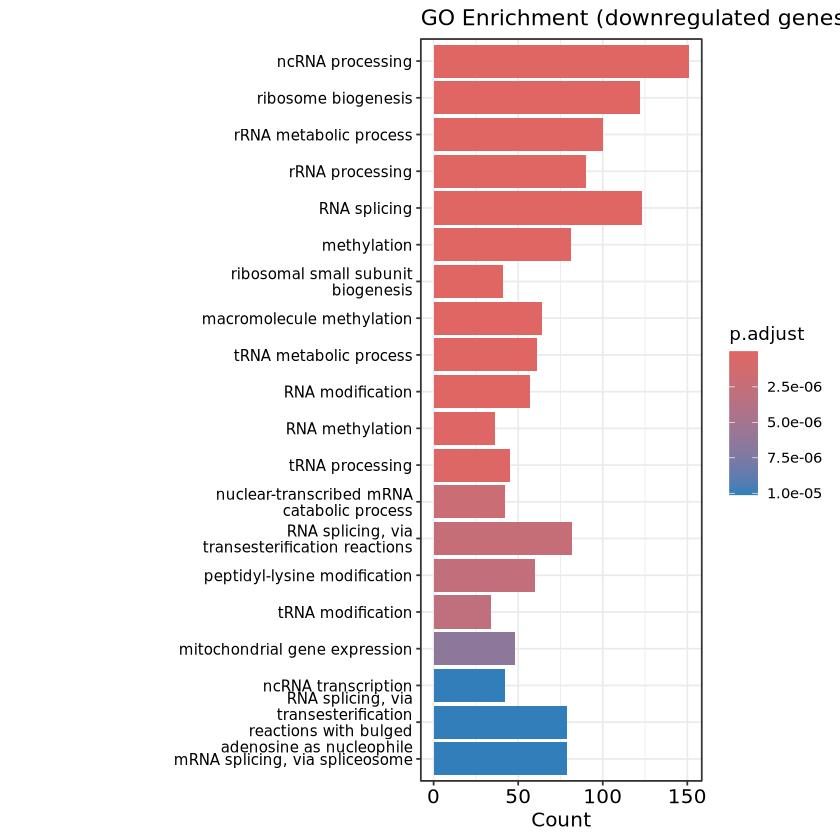

In [ ]:
# dotplot for downregulated genes
p_down_dot <- dotplot(
  ego_result_down_deseq,
  showCategory = 20,
  title = "GO Enrichment (downregulated genes deseq)",
  label_format = 35
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")  # extra space for long labels
  ) +
  coord_cartesian(clip = "off")

# barplot for downregulated genes
p_down_bar <- barplot(
  ego_result_down_deseq,
  showCategory = 20,
  title = "GO Enrichment (downregulated genes deseq)"
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")
  ) +
  coord_cartesian(clip = "off")

p_down_dot
p_down_bar

In [ ]:
# testing enrichr

In [ ]:
c2 <- read.gmt("/usr/users/papantonis1/aman/rnaseq_data/c2.all.v2025.1.Hs.symbols.gmt")
enrich_res <- enricher(up_df_annot$hgnc_symbol, TERM2GENE = c2)

In [ ]:
enrich_res

#
# over-representation test
#
#...@organism 	 UNKNOWN 
#...@ontology 	 UNKNOWN 
#...@gene 	 chr [1:9785] "TSPAN6" "FGR" "FUCA2" "CYP51A1" "AOC1" "CD38" "ARHGAP33" ...
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...511 enriched terms found
'data.frame':	511 obs. of  9 variables:
 $ ID         : chr  "REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION" "NABA_CORE_MATRISOME" "NABA_ECM_GLYCOPROTEINS" "MIKKELSEN_MCV6_HCP_WITH_H3K27ME3" ...
 $ Description: chr  "REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION" "NABA_CORE_MATRISOME" "NABA_ECM_GLYCOPROTEINS" "MIKKELSEN_MCV6_HCP_WITH_H3K27ME3" ...
 $ GeneRatio  : chr  "138/4210" "118/4210" "83/4210" "145/4210" ...
 $ BgRatio    : chr  "321/22381" "275/22381" "196/22381" "438/22381" ...
 $ pvalue     : num  9.63e-24 2.04e-20 2.16e-14 4.65e-13 1.67e-12 ...
 $ p.adjust   : num  5.83e-20 6.19e-17 4.36e-11 7.04e-10 1.77e-09 ...
 $ qvalue     : num  4.99e-20 5.30e-17 3.74e-11 6.03e-10 1.52e-09 ...
 $ geneID     : chr  "ITGAL/ITGA2B/DCN/CD44/TIMP2/VCAN/CDH1/

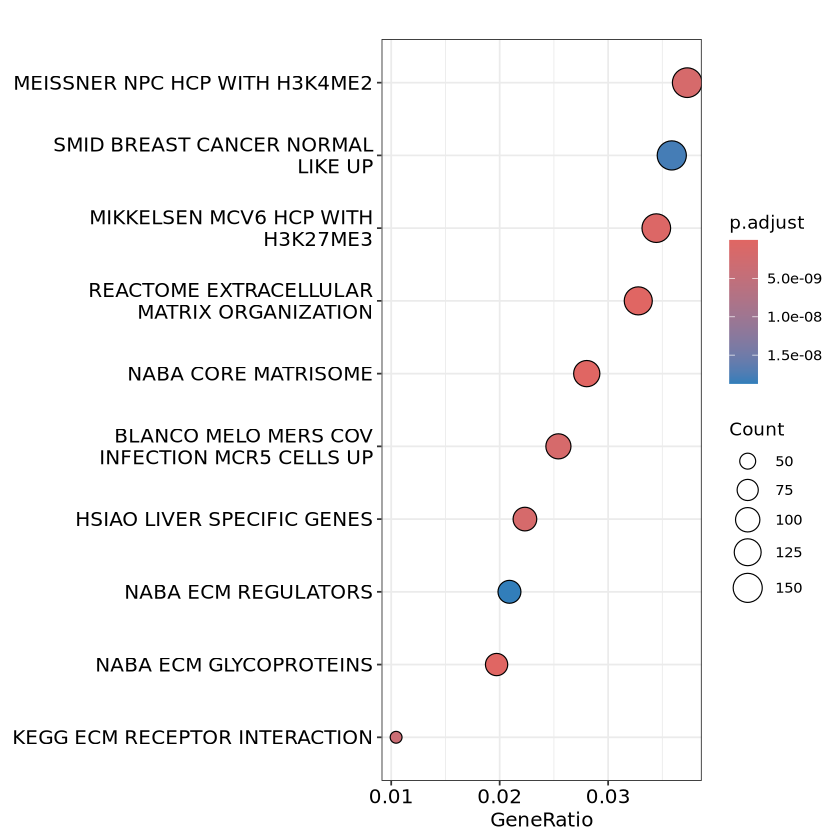

In [ ]:
dotplot(enrich_res)

In [ ]:
# All significant polycomb rel. set
subset(enrich_res@result, grepl("PRC2|POLYCOMB|H3K27|EZH2", Description, ignore.case = TRUE))

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,145/4210,438/22381,4.649644e-13,7.039561e-10,6.028631e-10,YBX2/CACNA1G/CACNA2D2/ADGRA2/TIMP2/CYP46A1/LAMC3/KCNQ1/CHRDL2/CAMK2B/LTK/DRD4/EPHA8/TRHDE/PANX2/TBX21/CACNG4/CHRNA3/DOCK3/EBF4/DLL3/EFNA2/SEZ6L/CABP7/CACNA1I/RIMS4/NECAB2/CORO2B/RASL12/COMP/TMEM59L/NPTX2/AEBP1/LHX3/FGF8/JHY/NRXN2/ASIC1/FGF12/GNB4/PODXL2/EFCC1/IL1RL2/CHD5/SLC8A2/PGF/ELOVL3/PRLHR/TGFBI/ADGRB2/HCRTR1/HS3ST2/PDE1B/MATN4/PTGIS/CPNE5/FIBCD1/BARX1/RAMP1/BCAN/ATP8A2/KL/SYT6/WNT2B/RAX/DYSF/MMD2/GABBR2/CCN3/ITPKA/RBP4/SEMA7A/DHH/SYT16/NTRK3/TMEM91/SYT2/PSD2/GFRA3/RASGEF1C/TCTE1/P4HA3/CDH22/DPYSL4/LGI2/FEZF2/KCNMA1/KCNS2/LYZL4/KLHL40/SLC34A2/ACAN/HTR6/FNDC5/CHRNB2/ALOX15/TRIM58/LMX1A/NEUROD1/FEV/IHH/GBX1/PHYHIPL/SLC6A5/LRTM2/LMO1/RRAD/KCNJ4/LGI3/MYRIP/ECEL1/COL8A2/C1QTNF4/ABCG4/SCUBE2/SCN4B/TMEM151B/GLDC/FOXE1/ALOX12B/HTR1D/SLC47A2/OXTR/HHIPL1/FAM43B/SYNDIG1L/AIFM3/CNTN2/KCNQ3/CCK/WDR86/SHISA7/SLC38A3/FBLL1/SKOR1/RELN/SLC6A17/L1CAM/DISP3/ONECUT3/GRID2IP/NPTXR/PCDHAC2/SPON1/RASL10B,145
MIKKELSEN_MEF_ICP_WITH_H3K27ME3,MIKKELSEN_MEF_ICP_WITH_H3K27ME3,MIKKELSEN_MEF_ICP_WITH_H3K27ME3,75/4210,207/22381,2.464786e-09,5.970699e-07,5.113264e-07,FGR/CHDH/POU2F2/WNT8B/COL4A4/PDYN/QPRT/ODAD1/ETV2/C5/ABCC3/VTN/APOA4/UPK2/PDE8B/PCDH12/GNAT1/CHRNB4/CA14/TNFRSF8/ARHGAP9/GDAP1L1/NRL/EPO/FAIM2/NR5A1/CD72/EGF/CYP1A2/KCNN3/ADGRG7/AHSG/DLG2/ANO4/TMEM45B/OLAH/PDE1C/ART3/LRRC43/LRRC36/TNFRSF13C/NPHS1/KCNJ9/ALPI/HESX1/TBATA/SLFN5/CD3D/LPO/ENTPD3/PHYHIP/COL4A3/NSG2/TTLL6/PIK3CD/MST1/SPATA3/SEZ6L2/PRSS36/ARID3B/ALOX15B/CFAP65/PNMA8A/PLCXD3/HEPACAM2/RYR1/AVPR1B/LY6G6C/C6orf15/PKHD1L1/SYT3/LINGO4/LEFTY1/C11orf97/C17orf50,75
MEISSNER_NPC_HCP_WITH_H3K4ME2_AND_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K4ME2_AND_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K4ME2_AND_H3K27ME3,107/4210,351/22381,7.685278e-08,9.308409e-06,7.971656e-06,CACNA2D2/CDH1/PTGER3/CBLN4/P4HA2/TBX21/GNAS/TESC/POU4F3/SLC26A4/CABP7/CACNA1I/NFATC2/PROKR2/MAST1/DNAH11/LHX6/FGF8/KCNA1/SIM1/NPR3/SLC30A3/TLX2/WNT6/OPRD1/LTBP2/HCRTR1/GHSR/FLT3/SLC12A5/CPNE5/KIRREL2/A4GALT/GALR3/FIBCD1/PTGFRN/RERG/PRPH/GABBR2/SEMA7A/STAC2/SYT14/SYT2/STXBP5L/RASGEF1C/SCUBE3/SLC22A3/ST8SIA6/POU4F2/TMEM163/KCNS2/B3GNT7/ACAN/COLEC12/GJD2/ABCG1/IKZF3/WNT4/LMX1A/FEV/IHH/UCN/EGFLAM/TLX3/GBX1/SPINT1/GNG4/INSM2/HR/CPLX1/GSX1/MYRIP/FOXD4/NEUROD2/ECEL1/PODN/SYNE3/SCN4B/KCNA3/PGBD5/FOXE1/TMEM151A/GATA2/RGS6/FAM43B/GJD3/SYNDIG1L/BMP8A/CNTN2/LRRC26/NOTUM/C12orf56/FFAR4/FBLL1/PAQR9/HMX3/ANKRD34B/ELAVL3/SLC6A17/DMBX1/RYR2/ARID3C/ONECUT3/NPTXR/TMEM150C/XKR7/SRCIN1,107
MIKKELSEN_ES_ICP_WITH_H3K4ME3_AND_H3K27ME3,MIKKELSEN_ES_ICP_WITH_H3K4ME3_AND_H3K27ME3,MIKKELSEN_ES_ICP_WITH_H3K4ME3_AND_H3K27ME3,50/4210,136/22381,6.388437e-07,5.253844e-05,4.499355e-05,CD44/BEST2/COL4A4/FXYD5/TEKT2/PTGS1/OSM/PAPLN/PDYN/ETV2/TFPI2/PTN/CNTNAP1/ABCC3/LAMA4/PDE8B/GNAT1/TNFRSF8/PTGFR/FGL2/MCHR1/GGT7/DSC3/GPNMB/NR5A1/REM2/SUSD4/KCNN3/PTH2R/TMEM45B/PDE1C/TNFRSF13C/MELTF/TBATA/SLFN5/PHYHIP/COL4A3/PROKR1/SEZ6L2/PRSS36/RFLNA/ALOX15B/NRBP2/GPAT2/CDHR4/PIWIL2/AVPR1B/MFSD2B/PSMB11/LEFTY1,50
MIKKELSEN_MCV6_ICP_WITH_H3K27ME3,MIKKELSEN_MCV6_ICP_WITH_H3K27ME3,MIKKELSEN_MCV6_ICP_WITH_H3K27ME3,32/4210,76/22381,2.324581e-06,1.530181e-04,1.310436e-04,SCN4A/POU2F2/WNT8B/ASB2/PDYN/ASIP/ETV2/VTN/SOX6/PCDH12/APC2/CHRNB4/ARHGAP9/FGL2/ADM2/AIPL1/NRL/GGT7/PAK6/SECTM1/PROK1/ALPI/TBATA/LPO/PIK3CD/S100Z/CD7/TH/CD177/LINGO4/LEFTY1/GKN3P,32
MIKKELSEN_MEF_LCP_WITH_H3K27ME3,MIKKELSEN_MEF_LCP_WITH_H3K27ME3,MIKKELSEN_MEF_LCP_WITH_H3K27ME3,29/4210,71/22381,1.387225e-05,6.177233e-04,5.290139e-04,SLC4A1/SLC13A2/ATP1A2/TNFRSF9/CDHR2/SLC16A8/SLC17A7/PAX4/KCNIP3/PLCD4/FGF23/G6PC1/HAPLN2/ABCG5/HDC/SEPTIN12/MMEL1/PKLR/ABCG8/HTR3B/ADAMTS13/PDZK1IP1/SOST/SP7/KISS1/NHLH1/SP6/LRCOL1/CCDC187,29
MEISSNER_NPC_HCP_WITH_H3K4ME3_AND_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K4ME3_AND_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K4ME3_AND_H3K27ME3,48/4210,143/223

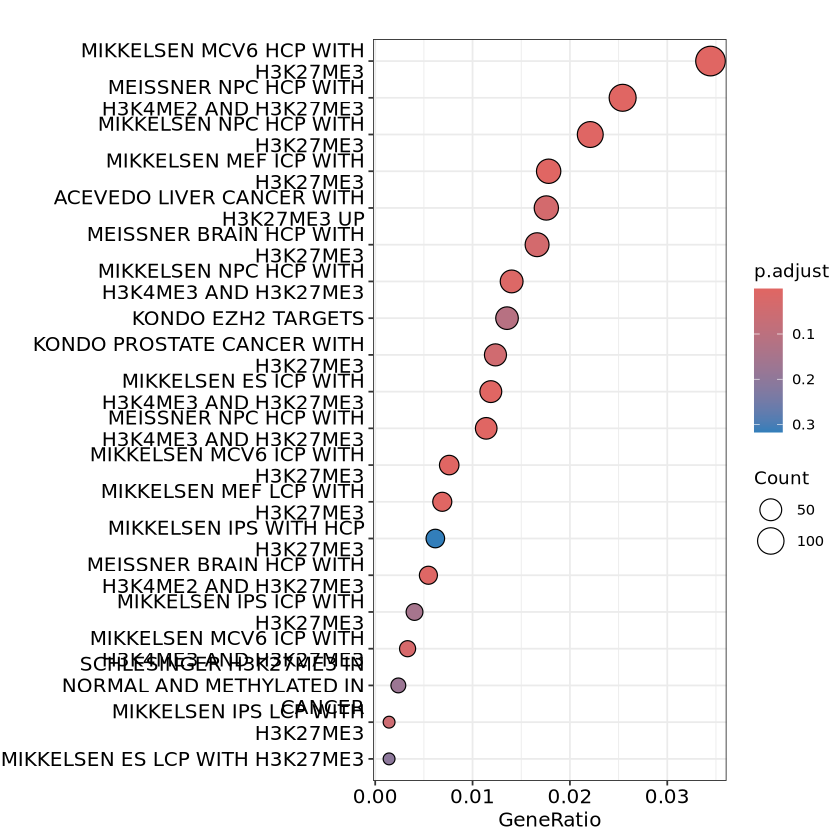

In [ ]:
library(clusterProfiler)

# Subset the result data.frame
prc2_df <- subset(enrich_res@result, grepl("PRC2|POLYCOMB|H3K27|EZH2", Description, ignore.case=TRUE))

# If prc2_df is not empty, create a new enrichResult
if (nrow(prc2_df) > 0) {
  # Copy enrich_res and replace @result with prc2_df
  prc2_res <- enrich_res
  prc2_res@result <- prc2_df
  prc2_res@pvalueCutoff <- 0.5
  prc2_res@qvalueCutoff <- 0.5
  dotplot(prc2_res, showCategory=50)
}

In [ ]:
# like this i could do with gsea too maybe?